In [2]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import *
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import welib
init_vprinting()

# 2 DOF
## Flexible Blade

In [3]:
t = sp.symbols('t')
g = sp.symbols('g')
q, psi = dynamicsymbols('q psi')
q_d, psi_d = dynamicsymbols('q psi', 1)

# Modal Integrals (Constants to be calculated later)
GM_b = sp.symbols('GM_b')           # Modal Mass: Integral(m * phi**2)
J_b = sp.symbols('J_b')             # Blade Inertia: Integral(m * r**2)
GM_coupling = sp.symbols('GM_coupling') # Rigid-Flex Coupling: Integral(m * r * phi)
m_b = sp.symbols('m_b')             # Total blade mass
r_cm = sp.symbols('r_cm')           # Blade CM location
K_b = sp.symbols('K_b')             # Modal Stiffness
J_hub = sp.symbols('J_hub')         # Hub/Shaft Inertia

In [8]:
N = ReferenceFrame('N')
# Rotor Frame R rotates about the X-axis (Shaft axis)
R = N.orientnew('R', 'Axis', [psi, N.x])

O = Point('O') # Hub Center
O.set_vel(N, 0)

In [9]:
# Energies
# Kinetic Energy
T_rot = sp.Rational(1,2) * (J_hub + J_b) * psi_d**2 # Rotational KE of hub and blade
T_flex = sp.Rational(1,2) * GM_b * q_d**2 # Flexural KE of blade
T = T_rot + T_flex

# Potential Energy
h_cm = r_cm * sp.cos(psi) # Height of blade center of mass
V_grav = m_b * g * h_cm # Gravitational PE
V_elastic = sp.Rational(1,2) * K_b * q**2
V = V_grav + V_elastic

# Lagrangian
L = T - V

In [10]:
# Pass the Lagrangian, the list of generalized coordinates, and the inertial frame N
LM = LagrangesMethod(L, [q, psi], frame=N)

# Generate the equations
eom = LM.form_lagranges_equations()

# Extract matrices directly using built-in properties
M = sp.simplify(LM.mass_matrix)
F = sp.simplify(LM.forcing)

print("Mass Matrix (M):")
sp.pprint(M)
print("\nForcing Vector (F):")
sp.pprint(F)

Mass Matrix (M):
⎡GM_b       0     ⎤
⎢                 ⎥
⎣ 0    J_b + J_hub⎦

Forcing Vector (F):
⎡     -K_b⋅q(t)      ⎤
⎢                    ⎥
⎣g⋅m_b⋅r_cm⋅sin(ψ(t))⎦


Linearized Mass Matrix (M):


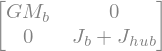

Linearized Stiffness Matrix (K):


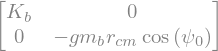

Linearized Damping/Gyroscopic Matrix (C):


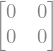

In [13]:
# # Operating Point 
# q0 = sp.symbols('q0')           # Steady-state flap deflection
# psi0 = sp.symbols('psi0')       # Azimuth angle
# Omega = sp.symbols('Omega')     # Steady rotor speed
# op_point = {q: q0, psi: psi0, q_d: 0, psi_d: Omega}

# M_lin = M.subs(op_point)

# # Linearized Damping Matrix: C = -dF/dq_dot
# C_lin = -F.jacobian([q_d, psi_d]).subs(op_point)

# # Linearized Stiffness Matrix: K = -dF/dq
# K_lin = -F.jacobian([q, psi]).subs(op_point)

# print("Linearized Mass Matrix (M_lin):")
# sp.pprint(M_lin)
# print("\nLinearized Damping Matrix (C_lin):")
# sp.pprint(C_lin)
# print("\nLinearized Stiffness Matrix (K_lin):")
# sp.pprint(K_lin)

q_0, psi_0 = sp.symbols('q_0 psi_0') # Steady-state positions (deflection and azimuth)
Omega = sp.symbols('Omega')          # Steady-state rotor spinning speed
op_point = {
    q: q_0,           
    q.diff(t): 0,         
    q.diff(t, 2): 0,      
    psi: psi_0,               
    psi.diff(t): Omega,         
    psi.diff(t, 2): 0         
}

# 3. Linearize
M_ss, A_ss, B_ss, _ = LM.linearize(
    q_ind=[q, psi],
    qd_ind=[q.diff(t), psi.diff(t)],
    op_point=op_point
)

# 4. Extract the 2x2 Structural Matrices
M_lin = M_ss[2:, 2:]    # Lower-right 2x2: Linearized Mass Matrix
K_lin = -A_ss[2:, :2]   # Lower-left 2x2: Linearized Stiffness Matrix
C_lin = -A_ss[2:, 2:]   # Lower-right 2x2: Linearized Damping/Gyroscopic Matrix

print('Linearized Mass Matrix (M):')
display(sp.simplify(M_lin))

print('Linearized Stiffness Matrix (K):')
display(sp.simplify(K_lin))

print('Linearized Damping/Gyroscopic Matrix (C):')
display(sp.simplify(C_lin))